In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


In [ ]:
import re
import pandas as pd
from pathlib import Path

path_list = [
    "logs/train/20251009_DDIM-100_215739_DL4",
    "logs/train/20251009_DDIM-10_205003_DL4",
    "logs/train/20251009_DDIM-5_215726_DL4",
    "logs/train/20251009_DDIM-1_215708_DL4",
]

df_list = []
for data_path in path_list:
    df = pd.read_json(Path(data_path) / 'records.jsonl', lines=True)
    if 'ade' not in df.columns: continue
    df = df[df['ade'].notna()]
    df['name'] = Path(data_path).name.split('_')[1]
    df_list.append(df)

df_record = pd.concat(df_list, ignore_index=True)
# df_record

In [4]:
df_list = []
for data_path in path_list:
    # 匹配 [20251009_DDPM-100-zara01_145545_DL4|train|N|Oct09 15:03:26|0:07:41.204367] [Epoch 20/10000] Overall: Loss=0.0077, ADE=0.3210, FDE=0.7062, AvgLen=3.1661, PedNum=5.8269, VehNum=0.0000, Time=1.1min (denoise=1.2s/it[86%]; embed data=86ms/it[6%]; visualize=1.0s/it[6%]; evaluate=78ms/it[0%]; rollout=6.3ms/it[0%]; prepare data=212ms/it[0%]; embed map=9.6ms/it[0%])
    with open(Path(data_path) / 'info.log', 'r') as f:
        for line in f.readlines():
            pattern = re.compile(
                r"\[(?P<name>[^|]*)\|.*?\]"
                r".*?\[Epoch (?P<epoch>\d+)/\d+\]"
                r".*?Overall",
                re.DOTALL
            )
            match = pattern.search(line)
            if not match: continue
            
            time_pattern = re.compile(
                r"(denoise|embed data|rollout)=([\d\.]+[um]?s)/it"
            )
            time_matches = time_pattern.findall(line)

            # --- 结果整合 ---
            row = match.groupdict()
            for key, val in time_matches:
                # 将空格替换成下划线作为字段名，例如 "embed data" -> "embed_data"
                key = key.replace(" ", "_")
                val = val.replace('ms', 'e-3').replace('us', 'e-6').replace('s', '')
                row[key] = float(val)
            row['name'] = row['name'].split('_')[1]
            row['epoch'] = int(row['epoch'])
            df_list.append(row)
df_log = pd.DataFrame(df_list)

(0.8, 0.95)

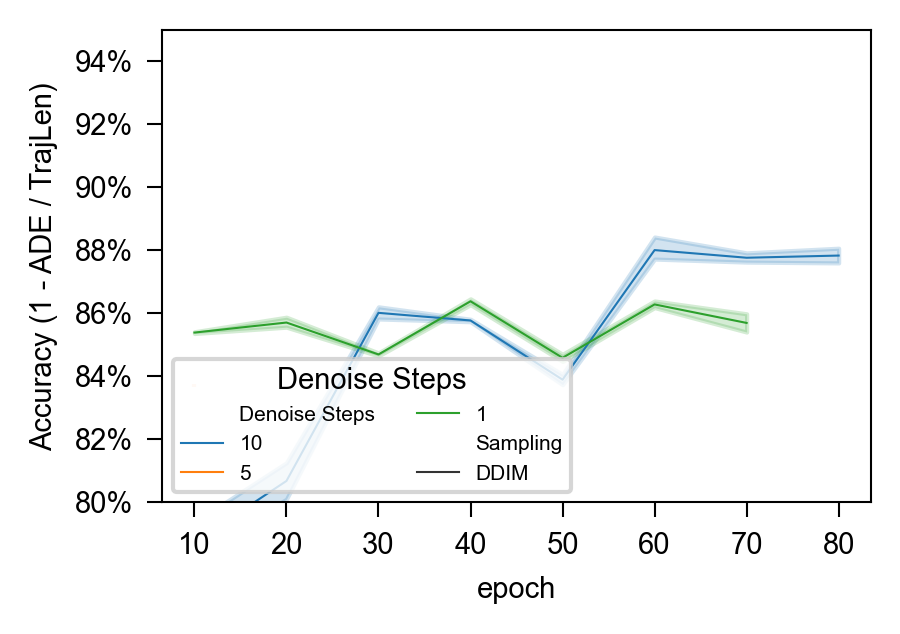

In [5]:
import numpy as np
from src.utils.plot import plt, sns, get_fig

df = pd.merge(df_record, df_log, on=['name', 'epoch'], how='inner')

df['Sampling'] = df['name'].apply(lambda x: x.split('-')[0])
df['Denoise Steps'] = df['name'].apply(lambda x: x.split('-')[1])
df['Accuracy'] = 1 - df['ade'].apply(np.mean) / df['trajlen'].apply(np.mean)
df['Time per Step (s)'] = df['embed_data'] + df['denoise'] + df['rollout']
# df[['name', 'epoch', 'accuracy']].set_index(['name', 'epoch']).sort_index()
df.head(5)


fi, fig, axes = get_fig(1, 1, AW=6, AH=4, HS=5, VS=5, dpi=300)

sns.lineplot(data=df, x='epoch', y='Accuracy', hue='Denoise Steps', style='Sampling', ax=axes[0], legend=True)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].set_ylabel('Accuracy (1 - ADE / TrajLen)')
# axes[0].axhline(0.85, color='red', linestyle='--')
axes[0].legend(title='Denoise Steps', loc='lower left', ncol=2, fontsize=5)
axes[0].set_ylim(0.8, 0.95)